In [ ]:
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 115.7 MB/s eta 0:00:00


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from __future__ import absolute_import, division, print_function
import codecs
import glob
import logging
import multiprocessing
import os
import pprint
import re
import keras
import nltk
import spacy
from nltk import ne_chunk, pos_tag
from nltk.tokenize import sent_tokenize, word_tokenize, PunktSentenceTokenizer
from nltk.corpus import stopwords
import gensim.models.word2vec as w2v
from gensim import logging
import sklearn.manifold
import numpy as np
import matplotlib.pyplot as plt
import pandas as  pd
import seaborn as sns
import pickle
import json
from nltk.tokenize import WhitespaceTokenizer
from nltk.tokenize import MWETokenizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Thesis/Agoda_Reviews_cleaned_v3.xlsx'
df_reviews = pd.read_excel(file_path)
reviews_list = df_reviews['clean_comments'].astype(str).tolist()

In [ ]:
def load_keywords(file_name):
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        return [x.strip() for x in lines if x.strip()]
    except FileNotFoundError:
        print(f"Không tìm thấy file {file_name}")
        return []

word_list_name = load_keywords('/content/drive/MyDrive/Thesis/Vocab/hotel_names_total.txt')
word_list_fac = load_keywords('/content/drive/MyDrive/Thesis/Vocab/facilities.txt')
word_list_loc = load_keywords('/content/drive/MyDrive/Thesis/Vocab/locations.txt')
word_list_price = load_keywords('/content/drive/MyDrive/Thesis/Vocab/Price.txt')
word_list_rel = load_keywords('/content/drive/MyDrive/Thesis/Vocab/located_relation.txt')
word_list_fac_rel = load_keywords('/content/drive/MyDrive/Thesis/Vocab/facility_relation.txt')
word_list_target = load_keywords('/content/drive/MyDrive/Thesis/Vocab/suitable_for.txt')

# lọc trùng và giữ nguyên thứ tự
def ordered_set(in_list):
    out_list = []
    added = set()
    for val in in_list:
        if not val in added:
            out_list.append(val)
            added.add(val)
    return out_list

all_keywords = word_list_name + word_list_fac + word_list_loc +word_list_rel + word_list_fac_rel + word_list_target
mw_list = []

for x in all_keywords:
    ws = x.split()
    if len(ws) > 1:
        # Chuyển thành tuple để spaCy hiểu đây là cụm từ cố định
        mw_list.append(tuple(ws))

mw_list = ordered_set(mw_list)

print(f"Đã chuẩn bị xong mw_list với {len(mw_list)} cụm từ.")
print("Ví dụ 5 cụm đầu tiên:", mw_list[0:10])



Đã chuẩn bị xong mw_list với 18926 cụm từ.
Ví dụ 5 cụm đầu tiên: [('118', 'Orchid'), ('1994', 'House'), ('2', 'Beautiful', 'Beach', 'View', 'bedrooms', 'New', 'Apartment'), ('20', 'Hotel', 'and', 'Apartment'), ('2001', 'Motel'), ('2005', 'Sea', '&', 'Horizon', 'Luxury', 'Apt', 'Full', 'Option'), ('22', 'Land', '71', 'Hang', 'Bong', 'Hotel'), ('22Land', 'Residence', 'Hotel'), ('22Housing', '39', 'Linh', 'Lang', 'Residence'), ('22Land', 'Classic', 'Suites')]


In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, MWETokenizer
from tqdm import tqdm

# 1. Tải các tài nguyên cần thiết
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

name_set = set(w.lower().strip() for w in word_list_name)
loc_set = set(w.lower().strip() for w in word_list_loc)
fac_set = set(w.lower().strip() for w in word_list_fac)
target_set = set(w.lower().strip() for w in word_list_target)
price_set = set(w.lower().strip() for w in word_list_price)

# 3. Khởi tạo MWETokenizer để không bị tách các cụm từ (ví dụ: "Cam Ranh", "Movenpick Resort")
def prepare_mwe(word_lists):
    combined_list = []
    for wl in word_lists:
        combined_list.extend(wl)
    # Chỉ lấy các cụm từ có từ 2 từ trở lên
    return [tuple(word.lower().split()) for word in combined_list if len(word.split()) > 1]

mwe = MWETokenizer()
all_lists = [word_list_name, word_list_loc, word_list_fac, word_list_target]
for phrase in prepare_mwe(all_lists):
    mwe.add_mwe(phrase)

all_item = []

# 4. TIẾN HÀNH DÁN NHÃN TRÊN DỮ LIỆU REVIEWS
for i in tqdm(range(len(df_reviews))):
    # Lấy câu review và đưa về chữ thường để so sánh
    text = str(df_reviews.clean_comments[i]).lower()

    # Tokenize
    tokens_raw = word_tokenize(text)
    tokens_mwe = mwe.tokenize(tokens_raw)

    sentence_words = []
    sentence_tags = []

    for token in tokens_mwe:
        # MWETokenizer nối cụm bằng '_', ta chuyển lại thành khoảng trắng để check dictionary
        clean_token = token.replace('_', ' ').strip()
        subwords = clean_token.split()

        # Xác định nhãn gốc bằng cách so khớp với bộ Set đã chuẩn bị
        label = "O"
        if clean_token in name_set: label = "ORG"
        elif clean_token in loc_set: label = "LOC"
        elif clean_token in fac_set: label = "FACILITY"
        elif clean_token in target_set: label = "TARGET"
        elif clean_token in price_set: label = "PRICE"

        # Gán nhãn B- và I- cho từng subword
        for idx, sw in enumerate(subwords):
            sentence_words.append(sw)
            if label != "O":
                tag = f"B-{label}" if idx == 0 else f"I-{label}"
            else:
                tag = "O"
            sentence_tags.append(tag)

    # Lấy POS Tag cho các từ trong câu
    pos_tags = [p[1] for p in nltk.pos_tag(sentence_words)]

    # Lưu vào danh sách tổng
    for w, p, t in zip(sentence_words, pos_tags, sentence_tags):
        all_item.append({
            'Sentence #': i + 1,
            'Word': w,
            'POS': p,
            'Tag': t
        })

# 5. XUẤT FILE VÀ KIỂM TRA LẠI
df_output = pd.DataFrame(all_item)

print("\n--- THỐNG KÊ NHÃN SAU KHI CHẠY LẠI ---")
print(df_output['Tag'].value_counts())

# Kiểm tra xem có nhãn LOC và FACILITY chưa
unique_tags = df_output['Tag'].unique()
print(f"\nCác nhãn thực tế thu được: {unique_tags}")

# Lưu file chuẩn bị cho Training
df_output.to_csv('data-loc-fac-bert_FULL.csv', sep='*', index=False, encoding="utf-8")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
  0%|          | 0/39205 [00:00<?, ?it/s]


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
print(f"Số lượng từ trong list Name: {len(word_list_name)}")
print(f"Số lượng từ trong list Loc: {len(word_list_loc)}")
print(f"Số lượng từ trong list Fac: {len(word_list_fac)}")
print(f"Số lượng từ trong list Target: {len(word_list_target)}")
print(f"Số lượng từ trong list price: {len(word_list_price)}")

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
from tqdm import tqdm, trange
#load data
# explore data
file_csv = 'data-loc-fac-bert_FULL.csv'
data = pd.read_csv(file_csv, sep='*',encoding="utf-8").fillna(method="ffill")

data.head(1000)


/tmp/ipykernel_1377/2170588429.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = pd.read_csv(file_csv, sep='*',encoding="utf-8").fillna(method="ffill")


,Sentence #,Word,POS,Tag
0,1,my,PRP$,B-ORG
1,1,wife,NN,O
2,1,and,CC,O
3,1,i,NN,O
4,1,recently,RB,O
...,...,...,...,...
995,3,for,IN,O
996,3,families,NNS,B-TARGET
997,3,and,CC,O
998,3,muslim,JJ,O


In [ ]:
import pandas as pd
from datasets import Dataset, Features, Sequence, Value, ClassLabel

# 1. Load dữ liệu
df = pd.read_csv('data-loc-fac-bert_FULL.csv', sep='*', encoding="utf-8")

# 2. Định nghĩa danh sách nhãn
label_list = ['O', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-FACILITY', 'I-FACILITY', 'B-TARGET', 'I-TARGET','B-PRICE']
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

# 3. Gom nhóm dữ liệu
# Đảm bảo Word luôn là string và Tag luôn là id (int)
agg_func = lambda s: [
    [str(w) for w in s["Word"].values.tolist()],
    [label2id[t] for t in s["Tag"].values.tolist()]
]

grouped = df.groupby("Sentence #").apply(agg_func, include_groups=False)
sentences = [s[0] for s in grouped]
labels = [s[1] for s in grouped]

# 4. ĐỊNH NGHĨA FEATURES (Bước quan trọng nhất để sửa lỗi ArrowInvalid)
# Việc khai báo Features giúp thư viện datasets biết chính xác kiểu dữ liệu, không tự đoán nữa.
features = Features({
    "tokens": Sequence(Value("string")),
    "ner_tags": Sequence(ClassLabel(names=label_list))
})

raw_data = {"tokens": sentences, "ner_tags": labels}
full_ds = Dataset.from_dict(raw_data, features=features)

ds_split = full_ds.train_test_split(test_size=0.3, seed=42)

print(ds_split["train"][0])

{'tokens': ['the', 'villa', 'is', 'located', 'in', 'a', 'villa', 'area', ',', 'with', 'spacious', 'roads', 'and', 'comfortable', 'parking', 'for', 'cars', '.', 'its', 'conveniently', 'located', 'near', 'the', 'center', '.', 'the', 'villa', 'is', 'quite', 'lovely', ',', 'and', 'the', 'cafe', 'and', 'breakfast', 'area', 'has', 'a', 'nice', 'chill', 'view', '.', 'the', 'owner', 'takes', 'great', 'care', 'of', 'the', 'garden', 'and', 'the', 'furnishings', 'in', 'the', 'room', '.', 'the', 'breakfast', 'includes', 'dishes', 'like', 'pho', ',', 'beef', 'noodle', 'soup', ',', 'and', 'h', 't', 'u', ',', 'which', 'are', 'quite', 'delicious', '.', 'the', 'accommodation', 'is', 'suitable', 'for', 'guests', 'who', 'appreciate', 'tranquility', ',', 'as', 'there', 'are', 'no', 'restaurants', 'within', 'a', '1', 'kilometers', 'radius', 'in', 'the', 'evening', '.', 'with', 'the', 'room', 'price', 'including', 'breakfast', ',', 'it', 'is', 'worth', 'the', 'money', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0,

In [ ]:
from transformers import AutoTokenizer

# bert-base-cased
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Ánh xạ token về từ gốc
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100) # Token đặc biệt (CLS, SEP) gán nhãn -100 để bỏ qua khi tính loss
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx]) # Token đầu tiên của từ
            else:
                label_ids.append(label[word_idx]) # Các token phụ sau đó gán cùng nhãn (hoặc dùng nhãn I-)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Map toàn bộ dataset qua hàm tokenize
tokenized_datasets = ds_split.map(tokenize_and_align_labels, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/27443 [00:00<?, ? examples/s]

Map:   0%|          | 0/11762 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer

# bert-base-cased
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, add_prefix_space=True)

def tokenize_and_align_labels(examples):
    # Nhớ đảm bảo cột chứa mảng từ của bạn tên là "tokens" hoặc đổi lại cho đúng
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True, # Bắt buộc phải có
        max_length=256 # Tùy chỉnh theo data của bạn
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]): # Đổi "ner_tags" thành tên cột nhãn của bạn
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # 1. Các special tokens (<s>, </s>) sẽ bị map thành None -> gán -100 để bỏ qua khi tính loss
            if word_idx is None:
                label_ids.append(-100)
            # 2. Token đầu tiên của một từ -> Gán nhãn gốc
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # 3. Các sub-token (token bị tách nhỏ) phía sau của cùng 1 từ -> gán -100
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Map toàn bộ dataset qua hàm tokenize
tokenized_datasets = ds_split.map(tokenize_and_align_labels, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/27443 [00:00<?, ? examples/s]

Map:   0%|          | 0/11762 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
import numpy as np

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.bias                 | MISSING    | 
classifier.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
args = TrainingArguments(
    f"{model_checkpoint}-finetuned-ner",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    push_to_hub=False,
)

In [ ]:
!pip install evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=387a456e3bd55d610fd2d6c8d4852293f96d94fc265603ee6ef09d50e6728717
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import evaluate
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Loại bỏ các vị trí đặc biệt (-100) trước khi tính điểm
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:

from transformers import DataCollatorForTokenClassification

# 1. Khai báo lại data_collator (vì đổi Runtime nên biến bị mất)
data_collator = DataCollatorForTokenClassification(tokenizer)

# 2. Khởi tạo lại Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
from transformers import DataCollatorForTokenClassification

# 1. Khai báo lại data_collator (vì đổi Runtime nên biến bị mất)
data_collator = DataCollatorForTokenClassification(tokenizer)

# 2. Khởi tạo lại Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# 3. Bắt đầu huấn luyện
trainer.train()




Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.019697,0.013952,0.970706,0.978409,0.974542,0.995729
2,0.010007,0.010227,0.977959,0.982911,0.980429,0.996742
3,0.006303,0.007999,0.984013,0.987265,0.985636,0.997544
4,0.004896,0.007501,0.984268,0.989649,0.986952,0.997756
5,0.003340,0.007466,0.986317,0.989702,0.988006,0.997873


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8580, training_loss=0.016064889204529892, metrics={'train_runtime': 660.1543, 'train_samples_per_second': 207.853, 'train_steps_per_second': 12.997, 'total_flos': 1.710863097824652e+16, 'train_loss': 0.016064889204529892, 'epoch': 5.0})

In [ ]:
save_directory = "/content/drive/MyDrive/Thesis/NER_Roberta_Model_v3"

trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"lưu model tại: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

lưu model tại: /content/drive/MyDrive/Thesis/NER_Roberta_Model_v3


In [ ]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
import pandas as pd

# 1. Đường dẫn tới thư mục đã lưu trên Drive
model_path = "/content/drive/MyDrive/Thesis/NER_Roberta_Model_v3"

# 2. Load model và tokenizer
model = AutoModelForTokenClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# 3. Tạo pipeline NER (aggregation_strategy="simple" giúp gộp các từ bị tách)
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## Fix trainer

In [ ]:
from seqeval.metrics import classification_report
import numpy as np
import time

start_time = time.time()

outputs = trainer.predict(tokenized_datasets["test"])
logits = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
predictions = np.argmax(logits, axis=-1)
labels = outputs.label_ids

# Ép kiểu label_list sang Tuple vì Tuple truy xuất dữ liệu trong bộ nhớ nhanh hơn List
label_tuple = tuple(label_list)

# Dùng Zip và List Comprehension nhưng đã lược bỏ các tính toán thừa
true_predictions = [
    [label_tuple[p] for p, l in zip(pred, lab) if l != -100]
    for pred, lab in zip(predictions.tolist(), labels.tolist())
    # .tolist() chuyển numpy array sang list Python trước để vòng lặp for chạy nhanh hơn
]

true_labels = [
    [label_tuple[l] for l in lab if l != -100]
    for lab in labels.tolist()
]

print("BẢNG CHỈ SỐ CỦA ROBERTA (Định dạng seqeval):")
print(classification_report(true_labels, true_predictions, zero_division=0))

print(f"⏱️ Thời gian xử lý: {time.time() - start_time:.4f} giây")

BẢNG CHỈ SỐ CỦA ROBERTA (Định dạng seqeval):
              precision    recall  f1-score   support

    FACILITY       1.00      1.00      1.00     47891
         LOC       0.95      0.97      0.96      7616
         ORG       0.97      0.98      0.98     29293
       PRICE       1.00      1.00      1.00      6420
      TARGET       1.00      1.00      1.00      3169

   micro avg       0.99      0.99      0.99     94389
   macro avg       0.98      0.99      0.99     94389
weighted avg       0.99      0.99      0.99     94389

⏱️ Thời gian xử lý: 28.4931 giây


In [ ]:

results = []

for index, row in df_reviews.head(500).iterrows():
    text = str(row['clean_comments'])

    ner_results = ner_pipeline(text)

    for entity in ner_results:
        results.append({
            "Sentence_Index": index,
            "Text": text,
            "Entity": entity['word'],
            "Label": entity['entity_group'], # Sẽ ra ORG, LOC, FACILITY...
            "Score": entity['score'] # Độ tự tin của model
        })

df_extracted = pd.DataFrame(results)
display(df_extracted.head(50))

df_extracted.to_csv("extracted_entities_results.csv", index=False)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Sentence_Index,Text,Entity,Label,Score
0,0,My wife and I recently enjoyed a wonderful thr...,My,ORG,0.999910
1,0,My wife and I recently enjoyed a wonderful thr...,night,ORG,0.999928
2,0,My wife and I recently enjoyed a wonderful thr...,at,ORG,0.999943
3,0,My wife and I recently enjoyed a wonderful thr...,Havana hotel,ORG,0.622140
4,0,My wife and I recently enjoyed a wonderful thr...,N,ORG,0.999656
5,0,My wife and I recently enjoyed a wonderful thr...,ha Trang,ORG,0.860712
6,0,My wife and I recently enjoyed a wonderful thr...,front desk,FACILITY,0.999931
7,0,My wife and I recently enjoyed a wonderful thr...,the staff,FACILITY,0.999946
8,0,My wife and I recently enjoyed a wonderful thr...,room,FACILITY,0.999959
9,0,My wife and I recently enjoyed a wonderful thr...,bath,FACILITY,0.999950


In [ ]:
df_extracted[df_extracted['Label']== "ORG"]

,Sentence_Index,Text,Entity,Label,Score
0,0,My wife and I recently enjoyed a wonderful thr...,My,ORG,0.963988
1,0,My wife and I recently enjoyed a wonderful thr...,I,ORG,0.654847
2,0,My wife and I recently enjoyed a wonderful thr...,Havana hotel,ORG,0.526659
3,0,My wife and I recently enjoyed a wonderful thr...,N,ORG,0.995680
4,0,My wife and I recently enjoyed a wonderful thr...,ha Trang,ORG,0.987365
...,...,...,...,...,...
6702,498,"I just had a 3 day , 2 night vacation at a hot...",view,ORG,0.701543
6706,498,"I just had a 3 day , 2 night vacation at a hot...",beach,ORG,0.595284
6707,498,"I just had a 3 day , 2 night vacation at a hot...",I,ORG,0.556397
6708,498,"I just had a 3 day , 2 night vacation at a hot...",N,ORG,0.997353


--- THỐNG KÊ TRÍCH XUẤT BERT ---
Tổng số thực thể tìm thấy: 6715

Số lượng theo từng nhãn:
Label
FACILITY    4015
ORG         1539
LOC          515
TARGET       345
PRICE        301
Name: count, dtype: int64

Số thực thể có độ tự tin thấp (<0.7): 855


/tmp/ipykernel_913/404492954.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_extracted, x='Label', palette='viridis')


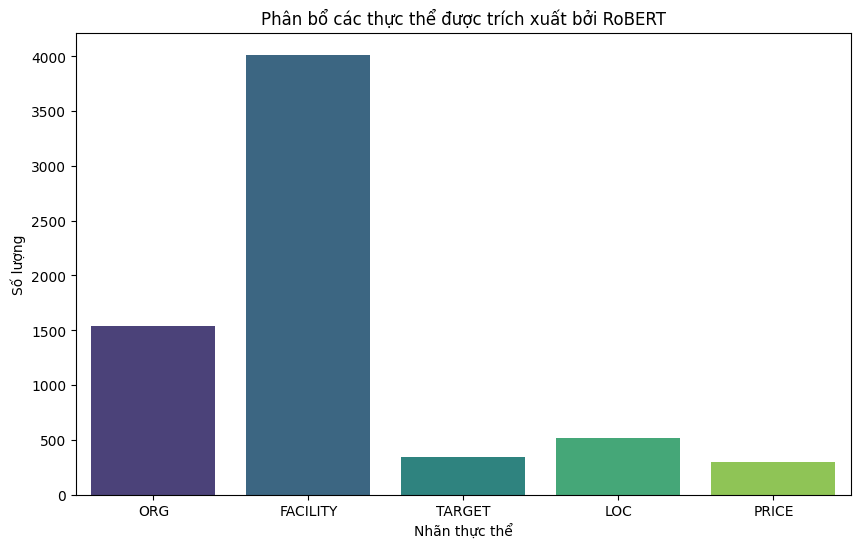

,Sentence_Index,Entity,Label,Confidence_Score,Context
0,0,My,ORG,0.9640,My wife and I recently enjoyed a wonderful thr...
1,0,I,ORG,0.6548,My wife and I recently enjoyed a wonderful thr...
2,0,Havana hotel,ORG,0.5267,My wife and I recently enjoyed a wonderful thr...
3,0,N,ORG,0.9957,My wife and I recently enjoyed a wonderful thr...
4,0,ha Trang,ORG,0.9874,My wife and I recently enjoyed a wonderful thr...
5,0,front desk,FACILITY,0.8080,My wife and I recently enjoyed a wonderful thr...
6,0,the staff,FACILITY,0.8783,My wife and I recently enjoyed a wonderful thr...
7,0,room,FACILITY,0.9803,My wife and I recently enjoyed a wonderful thr...
8,0,bathtub,FACILITY,0.7762,My wife and I recently enjoyed a wonderful thr...
9,0,my,ORG,0.7067,My wife and I recently enjoyed a wonderful thr...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chạy trích xuất (Dựa trên code của bạn)
results = []
for index, row in df_reviews.head(500).iterrows():
    text = str(row['clean_comments'])
    # ner_pipeline cần được set aggregation_strategy="simple" để gộp các sub-word thành word hoàn chỉnh
    ner_results = ner_pipeline(text)

    for entity in ner_results:
        results.append({
            "Sentence_Index": index,
            "Entity": entity['word'],
            "Label": entity['entity_group'],
            "Confidence_Score": round(entity['score'], 4),
            "Context": text[:100] + "..." # Lưu một ít ngữ cảnh để check nhanh
        })

df_extracted = pd.DataFrame(results)

# 2. Thống kê nhanh kết quả
print(f"--- THỐNG KÊ TRÍCH XUẤT BERT ---")
print(f"Tổng số thực thể tìm thấy: {len(df_extracted)}")
print("\nSố lượng theo từng nhãn:")
print(df_extracted['Label'].value_counts())

# 3. Lọc các thực thể có độ tự tin thấp (Potential Errors)
# Giúp bạn tìm nhanh các case máy đang phân vân để đưa vào phần Error Analysis
low_confidence = df_extracted[df_extracted['Confidence_Score'] < 0.7]
print(f"\nSố thực thể có độ tự tin thấp (<0.7): {len(low_confidence)}")

# 4. Trực quan hóa phân bổ nhãn (Dùng cho luận văn)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_extracted, x='Label', palette='viridis')
plt.title('Phân bổ các thực thể được trích xuất bởi RoBERT')
plt.xlabel('Nhãn thực thể')
plt.ylabel('Số lượng')
plt.show()

# 5. Lưu kết quả
df_extracted.to_csv("bert_ner_results_500.csv", index=False, encoding='utf-8-sig')
display(df_extracted.head(20))

In [ ]:
from sklearn.metrics import classification_report

def evaluate_transformer_model(model_pipeline, test_dataset):
    y_true_all = []
    y_pred_all = []

    print(f"Đang đánh giá trên {len(test_dataset)} câu bộ Test...")

    for i in range(len(test_dataset)):
        # 1. Lấy text gốc từ tokens (nối lại thành chuỗi)
        tokens = test_dataset[i]["tokens"]
        raw_text = " ".join(tokens)

        # 2. Lấy nhãn gốc (Gold Standard)
        # Chuyển từ ID (0, 1, 2...) về lại tên nhãn (B-LOC, I-FACILITY...)
        gold_tags = [label_list[t] for t in test_dataset[i]["ner_tags"]]

        # 3. Dự đoán bằng Pipeline
        # Dùng aggregation_strategy="simple" sẽ trả về các group thực thể
        preds = model_pipeline(raw_text)

        # Tạo một danh sách nhãn dự đoán mặc định toàn là 'O' có độ dài bằng số lượng tokens
        pred_tags = ["O"] * len(tokens)

        # Khớp kết quả từ pipeline vào danh sách tokens
        # (Vì Huggingface dùng character-level nên ta cần logic khớp nhẹ)
        for p in preds:
            p_text = p['word'].strip().lower()
            p_label = p['entity_group']

            for idx, t in enumerate(tokens):
                if t.lower() in p_text: # Khớp từ đơn giản
                    # Gán nhãn B- hoặc I- tùy vị trí (đơn giản hóa để đánh giá)
                    pred_tags[idx] = f"B-{p_label}" if "B-" not in pred_tags[idx] else f"I-{p_label}"

        y_true_all.extend(gold_tags)
        y_pred_all.extend(pred_tags)

    # 4. In báo cáo
    # Lọc bỏ nhãn 'O' để nhìn chỉ số các thực thể chính xác hơn
    labels_to_report = [l for l in label_list if l != 'O']
    print(classification_report(y_true_all, y_pred_all, labels=labels_to_report))

# Chạy lệnh
evaluate_transformer_model(ner_pipeline, ds_split["test"])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Đang đánh giá trên 11762 câu bộ Test...
              precision    recall  f1-score   support

       B-LOC       0.35      0.69      0.46      8181
       I-LOC       0.11      0.19      0.14      3686
       B-ORG       0.55      0.61      0.58     32143
       I-ORG       0.04      0.24      0.07      3303
  B-FACILITY       0.40      0.73      0.52     51477
  I-FACILITY       0.05      0.21      0.08      8112
    B-TARGET       0.47      0.76      0.58      3498
    I-TARGET       0.00      0.07      0.01       150
     B-PRICE       0.63      0.84      0.72      6970

   micro avg       0.34      0.63      0.44    117520
   macro avg       0.29      0.48      0.35    117520
weighted avg       0.41      0.63      0.49    117520



In [ ]:
from seqeval.metrics import classification_report
import numpy as np
import time

start_time = time.time()

# 1. Chạy dự đoán trên tập Test
print("Đang chạy dự đoán trên tập Test...")
outputs = trainer.predict(tokenized_datasets["test"])

# Xử lý trường hợp outputs.predictions trả về tuple (ví dụ model có trả về hidden states)
logits = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
predictions = np.argmax(logits, axis=-1)
labels = outputs.label_ids

# 2. Khôi phục lại nhãn dạng chữ (B-LOC, I-ORG, O...) và loại bỏ các token bị phớt lờ (-100)
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# 3. In bảng báo cáo chi tiết TỪNG NHÃN
print("\n" + "="*50)
print("BẢNG ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN (Dùng seqeval)")
print("="*50)
print(classification_report(true_labels, true_predictions, zero_division=0))

print(f"\n⏱️ Thời gian xử lý: {time.time() - start_time:.4f} giây")

Đang chạy dự đoán trên tập Test...



BẢNG ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN (Dùng seqeval)
              precision    recall  f1-score   support

    FACILITY       1.00      1.00      1.00     47891
         LOC       0.95      0.97      0.96      7616
         ORG       0.97      0.98      0.98     29293
       PRICE       1.00      1.00      1.00      6420
      TARGET       1.00      1.00      1.00      3169

   micro avg       0.99      0.99      0.99     94389
   macro avg       0.98      0.99      0.99     94389
weighted avg       0.99      0.99      0.99     94389


⏱️ Thời gian xử lý: 28.3316 giây


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Dự đoán trực tiếp trên tập Test đã chuẩn hóa (Siêu nhanh)
print(f"Đang đánh giá trực tiếp từ kiến trúc model...")
outputs = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(outputs.predictions, axis=-1)
labels = outputs.label_ids

# 2. Khử token đặc biệt (-100)
mask = labels != -100
y_true = labels[mask]
y_pred = predictions[mask]

# 3. Lấy đúng danh sách tên nhãn từ model config
# Điều này đảm bảo ID 1 là B-LOC thì dự đoán 1 cũng hiện là B-LOC
target_names = [model.config.id2label[i] for i in range(len(model.config.id2label))]

# 4. In báo cáo (Loại bỏ nhãn 'O' để soi kỹ các thực thể)
labels_ids_to_show = [i for i, label in model.config.id2label.items() if label != 'O']
target_names_to_show = [model.config.id2label[i] for i in labels_ids_to_show]

print("\n--- BÁO CÁO KẾT QUẢ CHUẨN ĐẾN TỪNG TOKEN ---")
print(classification_report(y_true, y_pred,
                            labels=labels_ids_to_show,
                            target_names=target_names_to_show,
                            zero_division=0))

Đang đánh giá trực tiếp từ kiến trúc model...



--- BÁO CÁO KẾT QUẢ CHUẨN ĐẾN TỪNG TOKEN ---
              precision    recall  f1-score   support

       B-LOC       0.97      0.98      0.97      7616
       I-LOC       0.91      0.96      0.94      3411
       B-ORG       0.99      0.99      0.99     29293
       I-ORG       0.83      0.88      0.86      2997
  B-FACILITY       1.00      1.00      1.00     47891
  I-FACILITY       0.99      0.99      0.99      7621
    B-TARGET       1.00      1.00      1.00      3169
    I-TARGET       0.97      0.99      0.98       138
     B-PRICE       1.00      1.00      1.00      6420

   micro avg       0.98      0.99      0.99    108556
   macro avg       0.96      0.98      0.97    108556
weighted avg       0.98      0.99      0.99    108556



### Check tay nhãn

In [ ]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
from spacy import displacy
from ipywidgets import IntProgress
from IPython.display import display
import torch

# 1. Load model RoBERTa từ Drive
model_path = "/content/drive/MyDrive/Thesis/NER_Roberta_Model_v3"
model = AutoModelForTokenClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Lấy nhãn từ config của model để hiển thị đúng tên (FACILITY, ORG...)
id2label = model.config.id2label

# 2. Tạo pipeline
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# 3. Lấy dữ liệu từ ds_split["test"]
test_data = ds_split["test"]

count = 0
total_predicted = 0
total_annote = 0

# Thanh tiến trình
f = IntProgress(min=0, max=min(100, len(test_data))) # Chỉ check 100 câu đầu
display(f)

print("--- KIỂM TRA 100 CÂU ĐẦU VỚI ROBERTA (TRÍCH XUẤT TỪ DS_SPLIT) ---")

for i in range(min(100, len(test_data))):
    f.value += 1

    # --- PHỤC HỒI TEXT VÀ NHÃN GỐC ---
    # ds_split lưu dạng list tokens, ta cần nối lại thành câu để pipeline chạy
    item = test_data[i]
    tokens = item['tokens']
    ner_tags = item['ner_tags']

    # Tạo text và xác định vị trí nhãn gốc (gold entities)
    text = ""
    gold_ents = []
    current_pos = 0

    for tok, tag_id in zip(tokens, ner_tags):
        start = current_pos
        text += tok + " "
        end = current_pos + len(tok)

        # Nếu tag_id không phải 'O' (giả sử 'O' có ID là 0)
        label = id2label[tag_id]
        if label != 'O':
            # Loại bỏ tiền tố B- hoặc I- để displacy gom nhóm đẹp hơn
            clean_label = label.replace("B-", "").replace("I-", "")
            gold_ents.append({'start': start, 'end': end, 'label': clean_label})

        current_pos += len(tok) + 1 # +1 cho khoảng trắng

    # --- MÁY DỰ ĐOÁN (PREDICTED) ---
    ner_results = ner_pipeline(text.strip())
    pred_ents = []
    for ent in ner_results:
        pred_ents.append({
            'start': ent['start'],
            'end': ent['end'],
            'label': ent['entity_group']
        })

    total_predicted += len(pred_ents)
    total_annote += len(gold_ents)

    # --- HIỂN THỊ SO SÁNH ---
    if count < 100:
        print(f"\n CÂU {count + 1}:")

        print(" MÁY ROBERTA ĐOÁN:")
        displacy.render({'text': text, 'ents': pred_ents},
                        jupyter=True, style='ent', manual=True)

        print(" NHÃN GỐC (GROUND TRUTH):")
        displacy.render({'text': text, 'ents': gold_ents},
                        jupyter=True, style='ent', manual=True)
        print("-" * 100)

    count += 1

print("\n--- KẾT QUẢ THỐNG KÊ (ROBERTA) ---")
print(f"Tổng số thực thể trong bộ Test (Annotated): {total_annote}")
print(f"Tổng số thực thể máy RoBERTa tìm được (Predicted): {total_predicted}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

IntProgress(value=0)

--- KIỂM TRA 100 CÂU ĐẦU VỚI ROBERTA (TRÍCH XUẤT TỪ DS_SPLIT) ---

 CÂU 1:
 MÁY ROBERTA ĐOÁN:


 NHÃN GỐC (GROUND TRUTH):


----------------------------------------------------------------------------------------------------

 CÂU 2:
 MÁY ROBERTA ĐOÁN:


...

----------------------------------------------------------------------------------------------------

 CÂU 99:
 MÁY ROBERTA ĐOÁN:


 NHÃN GỐC (GROUND TRUTH):


----------------------------------------------------------------------------------------------------

 CÂU 100:
 MÁY ROBERTA ĐOÁN:


 NHÃN GỐC (GROUND TRUTH):


----------------------------------------------------------------------------------------------------

--- KẾT QUẢ THỐNG KÊ (ROBERTA) ---
Tổng số thực thể trong bộ Test (Annotated): 845
Tổng số thực thể máy RoBERTa tìm được (Predicted): 769


In [ ]:
import pandas as pd

# 1. Đọc file dữ liệu
df_check = pd.read_csv('data-loc-fac-bert.csv', sep='*', encoding="utf-8")

# 2. Thống kê số lượng dòng cho mỗi nhãn
tag_counts = df_check['Tag'].value_counts()

# 3. Tính tỉ lệ phần trăm (%) để xem nhãn nào đang chiếm ưu thế
tag_percent = df_check['Tag'].value_counts(normalize=True) * 100

# 4. Gom nhóm thành một bảng thống kê chi tiết
summary_df = pd.DataFrame({
    'Số lượng': tag_counts,
    'Tỉ lệ (%)': tag_percent
})

print("--- THỐNG KÊ TẤT CẢ NHÃN TRONG FILE DATA-LOC-FAC-BERT ---")
print(summary_df)

# 5. Kiểm tra các thực thể tiêu biểu cho mỗi nhãn (Trừ nhãn 'O')
print("\n--- TOP 5 TỪ TIÊU BIỂU CHO MỖI NHÃN ---")
unique_tags = [t for t in tag_counts.index if t != 'O']

for tag in unique_tags:
    top_words = df_check[df_check['Tag'] == tag]['Word'].value_counts().head(5).index.tolist()
    print(f"{tag}: {', '.join(top_words)}")

print(df_check['Tag'].unique())